# Collect Motor Dataset With PD Control

This notebook sends configurable position/velocity targets to one motor using the hybrid PD form:

```text
Torque = kp * (target_qpos - actual_qpos) + kd * (target_qvel - actual_qvel)
```

It saves one CSV per continuous run. For compatibility with the torque dataset tools, the saved `qact` column contains the commanded target position. The notebook also saves `target_qvel`, `kp`, `kd`, and `qtorque_cmd`, where `qtorque_cmd = kp * (target_qpos - qpos) + kd * (target_qvel - qvel)` is the implied PD torque command computed from measured feedback.

During `collect_all`, the first measured position of the first run is used as the shared zero, so later runs keep their physical offset relative to the initial manual zero. The saved `qpos` column is shifted by that shared zero; `qpos_unshifted` stores the unwrapped feedback before this subtraction so zero drift is visible.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
SCRIPT_DIR = PROJECT_ROOT / "scripts"
BUILD_DIR = PROJECT_ROOT / "build"

for import_dir in (SCRIPT_DIR, BUILD_DIR):
    if import_dir.exists() and str(import_dir) not in sys.path:
        sys.path.insert(0, str(import_dir))

from motor_position import unwrap_motor_position

import encosid

/home/slava/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Configuration

Set the CAN interface, motor id, sample period, PD gains, output directory, and target limits before running collection. `RUN_COLLECTION` is guarded by default; enable it only when the motor/load are mechanically safe.

In [2]:
MOTOR_IF = "can0"

# MOTOR_ID_READ_1 = encosid.get_id(MOTOR_IF)
# MOTOR_ID_READ_2 = encosid.get_id(MOTOR_IF)
# if MOTOR_ID_READ_1 != MOTOR_ID_READ_2:
#     raise RuntimeError(
#         f"Motor id reads differ: first={MOTOR_ID_READ_1}, second={MOTOR_ID_READ_2}. "
#         "Check that only one motor is present on the CAN bus."
#     )
# MOTOR_ID = MOTOR_ID_READ_2
MOTOR_ID = 3
print(f"Using motor id {MOTOR_ID} from {MOTOR_IF}")

DT_MS = 1

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "data" / "raw_pd_encos_servant"

# src/encos.cpp encodes target position in [-10, 10] and target velocity in [-20, 20].
# 7 rad allows a single 2*pi rotation while keeping margin from the encoder limit.
MAX_ABS_TARGET_QPOS = 7.0
MAX_ABS_TARGET_QVEL = 15.0
QVEL_FEEDBACK_LIMIT = 20.0
QVEL_WARNING_LIMIT = 18.0
QTORQUE_CMD_WARNING_LIMIT = 90.0

RUN_COLLECTION = True

# Move back to zero after each saved run so the next run starts near qpos=0.
# The return motion is not saved into the dataset.
RETURN_TO_ZERO_AFTER_RUN = True
RETURN_TO_ZERO_DURATION_S = 3.0
RETURN_TO_ZERO_TARGET_QPOS = 0.0
RETURN_TO_ZERO_KP = 10.0
RETURN_TO_ZERO_KD = 1.0
RETURN_TO_ZERO_PAUSE_S = 3


@dataclass(frozen=True)
class RunSpec:
    name: str
    kind: str
    duration_s: float
    kp: float
    kd: float
    center: float = 0.0
    amplitude: float = 0.0
    f_hz: float | None = None
    f0_hz: float | None = None
    f1_hz: float | None = None
    step_s: float | None = None
    pulse_s: float | None = None
    end: float | None = None
    seed: int | None = None
    target_qvel: float = 0.0


RUN_PLAN = [
    # Optional full rotation. Keep commented until the position scale is verified.
    # RunSpec(name="pd_slow_rotation_2pi_30s_kp6_kd1", kind="linear", duration_s=30.0, center=0.0, end=2 * np.pi, kp=6.0, kd=1.0),

    # RunSpec(name="pd_hold_qpos0_kp6_kd0p8", kind="constant", duration_s=3.0, center=0.0, kp=6.0, kd=0.8),
    # RunSpec(name="pd_linear_qpos_0_to_1p6_8s_kp20_kd0p8", kind="linear", duration_s=8.0, center=0.0, end=1.6, kp=20.0, kd=0.8),
    # RunSpec(name="pd_sine_qpos_amp0p5_0p25hz_kp6_kd0p8", kind="sine", duration_s=8.0, amplitude=0.5, f_hz=0.25, kp=10.0, kd=0.8),
    # RunSpec(name="pd_sine_qpos_amp1p6_0p5hz_kp20_kd1", kind="sine", duration_s=5.0, amplitude=1.6, f_hz=0.5, kp=20.0, kd=1.0),
    # RunSpec(name="pd_chirp_qpos_amp0p5_0p1_1p5hz_kp30_kd1p5", kind="chirp", duration_s=10.0, amplitude=0.5, f0_hz=0.1, f1_hz=1.5, kp=30.0, kd=1.5),
    # RunSpec(name="pd_chirp_qpos_amp0p4_0p1_1p5hz_kp8_kd1", kind="chirp", duration_s=10.0, amplitude=0.3, f0_hz=0.1, f1_hz=1.5, kp=20.0, kd=1.3),
    # RunSpec(name="pd_chirp_qpos_amp0p4_0p1_2hz_kp10_kd1", kind="chirp", duration_s=12.0, amplitude=0.4, f0_hz=0.1, f1_hz=2.0, kp=15.0, kd=1.2),
    # RunSpec(name="pd_chirp_qpos_amp0p6_0p1_2hz_kp10_kd1", kind="chirp", duration_s=12.0, amplitude=0.6, f0_hz=0.1, f1_hz=2.0, kp=15.0, kd=1.5),
    RunSpec(name="pd_steps_qpos_amp1p0_800ms_s9_kp25_kd0p8", kind="random_steps", duration_s=10.0, amplitude=1.0, step_s=0.8, seed=9, kp=25.0, kd=0.8),
    # RunSpec(name="pd_steps_qpos_amp1p2_500ms_s7_kp20_kd1", kind="random_steps", duration_s=10.0, amplitude=1.2, step_s=0.5, seed=7, kp=20.0, kd=1.0),
    # RunSpec(name="pd_steps_qpos_amp1p2_1000ms_s3_kp40_kd4", kind="random_steps", duration_s=10.0, amplitude=1.2, step_s=1.0, seed=3, kp=40.0, kd=4.0),
    # RunSpec(name="pd_steps_qpos_amp1p4_500ms_s4_kp10_kd4", kind="random_steps", duration_s=10.0, amplitude=1.4, step_s=0.5, seed=4, kp=10.0, kd=4.0),
    # RunSpec(name="pd_pulses_qpos_amp0p4_150ms_800ms_s3_kp30_kd3", kind="random_pulses", duration_s=10.0, amplitude=0.4, step_s=0.8, pulse_s=0.15, seed=3, kp=30.0, kd=3.0),
    # RunSpec(name="pd_pulses_qpos_amp1p0_400ms_800ms_s3_kp20_kd1", kind="random_pulses", duration_s=10.0, amplitude=1.0, step_s=0.8, pulse_s=0.4, seed=4, kp=20.0, kd=1.0),
]

Using motor id 3 from can0


## Set Motor Zero

This notebook resets the motor feedback position to zero before collection. Place the motor mechanically at the desired zero position before running this cell. The current `encosid.set_zero` helper broadcasts through the CAN interface and is intended for a single motor on the bus.

In [3]:
print(f"Setting motor zero on {MOTOR_IF}. Make sure only the intended motor is on the bus.")
encosid.set_zero(MOTOR_IF)
print("Motor zero command completed.")

Setting motor zero on can0. Make sure only the intended motor is on the bus.
Motor zero command completed.


Found id #3


## Build Target Signals

In [4]:
def time_axis(duration_s: float, dt_ms: float = DT_MS) -> np.ndarray:
    sample_count = int(round(duration_s * 1000 / dt_ms))
    return np.arange(sample_count, dtype=float) * dt_ms * 1e-3


def require_value(value: float | None, field_name: str, spec: RunSpec) -> float:
    if value is None:
        raise ValueError(f"{spec.name} requires {field_name}")
    return value


def constant_signal(t: np.ndarray, center: float) -> np.ndarray:
    return np.full_like(t, center, dtype=float)


def linear_signal(t: np.ndarray, start: float, end: float) -> np.ndarray:
    if len(t) == 0:
        return np.array([], dtype=float)
    duration_s = t[-1] + (t[1] - t[0] if len(t) > 1 else DT_MS * 1e-3)
    return start + (end - start) * t / duration_s


def sine_signal(t: np.ndarray, center: float, amplitude: float, f_hz: float) -> np.ndarray:
    return center + amplitude * np.sin(2 * np.pi * f_hz * t)


def chirp_signal(t: np.ndarray, center: float, amplitude: float, f0_hz: float, f1_hz: float) -> np.ndarray:
    if len(t) == 0:
        return np.array([], dtype=float)
    duration_s = t[-1] + (t[1] - t[0] if len(t) > 1 else DT_MS * 1e-3)
    sweep_rate = (f1_hz - f0_hz) / duration_s
    phase = 2 * np.pi * (f0_hz * t + 0.5 * sweep_rate * t**2)
    return center + amplitude * np.sin(phase)


def random_step_signal(
    t: np.ndarray,
    center: float,
    amplitude: float,
    step_s: float,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    if len(t) == 0:
        return np.array([], dtype=float)
    dt_s = t[1] - t[0] if len(t) > 1 else DT_MS * 1e-3
    samples_per_step = max(1, int(round(step_s / dt_s)))
    step_count = int(np.ceil(len(t) / samples_per_step))
    levels = center + rng.uniform(-amplitude, amplitude, size=step_count)
    return np.repeat(levels, samples_per_step)[: len(t)]


def random_pulse_signal(
    t: np.ndarray,
    center: float,
    amplitude: float,
    period_s: float,
    pulse_s: float,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    if len(t) == 0:
        return np.array([], dtype=float)
    if pulse_s <= 0 or period_s <= 0 or pulse_s > period_s:
        raise ValueError("pulse_s must be positive and no larger than period_s")

    dt_s = t[1] - t[0] if len(t) > 1 else DT_MS * 1e-3
    samples_per_period = max(1, int(round(period_s / dt_s)))
    samples_per_pulse = max(1, int(round(pulse_s / dt_s)))
    period_count = int(np.ceil(len(t) / samples_per_period))
    levels = center + rng.uniform(-amplitude, amplitude, size=period_count)

    signal = np.full_like(t, center, dtype=float)
    for period_idx, level in enumerate(levels):
        start = period_idx * samples_per_period
        stop = min(start + samples_per_pulse, len(signal))
        signal[start:stop] = level
    return signal


def estimate_target_velocity(
    t: np.ndarray,
    target_qpos: np.ndarray,
    fallback: float,
    kind: str,
) -> np.ndarray:
    # Step and pulse position targets are discontinuous. Differentiating them
    # creates unsafe velocity spikes, so request the configured fallback velocity.
    if kind in {"constant", "random_steps", "random_pulses"} or len(target_qpos) < 2:
        return np.full_like(target_qpos, fallback, dtype=float)
    return np.gradient(target_qpos, t)


def build_targets(spec: RunSpec, dt_ms: float = DT_MS) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    t = time_axis(spec.duration_s, dt_ms)

    if spec.kind == "constant":
        target_qpos = constant_signal(t, spec.center)
    elif spec.kind == "linear":
        target_qpos = linear_signal(t, spec.center, require_value(spec.end, "end", spec))
    elif spec.kind == "sine":
        target_qpos = sine_signal(t, spec.center, spec.amplitude, require_value(spec.f_hz, "f_hz", spec))
    elif spec.kind == "chirp":
        target_qpos = chirp_signal(
            t,
            spec.center,
            spec.amplitude,
            require_value(spec.f0_hz, "f0_hz", spec),
            require_value(spec.f1_hz, "f1_hz", spec),
        )
    elif spec.kind == "random_steps":
        target_qpos = random_step_signal(t, spec.center, spec.amplitude, require_value(spec.step_s, "step_s", spec), spec.seed)
    elif spec.kind == "random_pulses":
        target_qpos = random_pulse_signal(
            t,
            spec.center,
            spec.amplitude,
            require_value(spec.step_s, "step_s", spec),
            require_value(spec.pulse_s, "pulse_s", spec),
            spec.seed,
        )
    else:
        raise ValueError(f"Unsupported signal kind: {spec.kind}")

    target_qpos = np.asarray(target_qpos, dtype=float)
    target_qvel = estimate_target_velocity(t, target_qpos, spec.target_qvel, spec.kind)

    max_abs_qpos = np.max(np.abs(target_qpos), initial=0.0)
    max_abs_qvel = np.max(np.abs(target_qvel), initial=0.0)
    if max_abs_qpos > MAX_ABS_TARGET_QPOS:
        raise ValueError(
            f"{spec.name} exceeds MAX_ABS_TARGET_QPOS={MAX_ABS_TARGET_QPOS}: "
            f"max abs target qpos is {max_abs_qpos:.3f}"
        )
    if max_abs_qvel > MAX_ABS_TARGET_QVEL:
        raise ValueError(
            f"{spec.name} exceeds MAX_ABS_TARGET_QVEL={MAX_ABS_TARGET_QVEL}: "
            f"max abs target qvel is {max_abs_qvel:.3f}"
        )

    return t, target_qpos, target_qvel

In [5]:
for spec in RUN_PLAN:
    t, target_qpos, target_qvel = build_targets(spec)
    print(
        f"{spec.name}: {len(target_qpos)} samples, "
        f"{t[-1] + DT_MS * 1e-3:.3f} s, "
        f"kp={spec.kp:.3f}, kd={spec.kd:.3f}, "
        f"target qpos range [{target_qpos.min():.3f}, {target_qpos.max():.3f}], "
        f"target qvel range [{target_qvel.min():.3f}, {target_qvel.max():.3f}]"
    )

pd_steps_qpos_amp1p0_800ms_s9_kp25_kd0p8: 10000 samples, 10.000 s, kp=25.000, kd=0.800, target qpos range [-0.989, 0.836], target qvel range [0.000, 0.000]


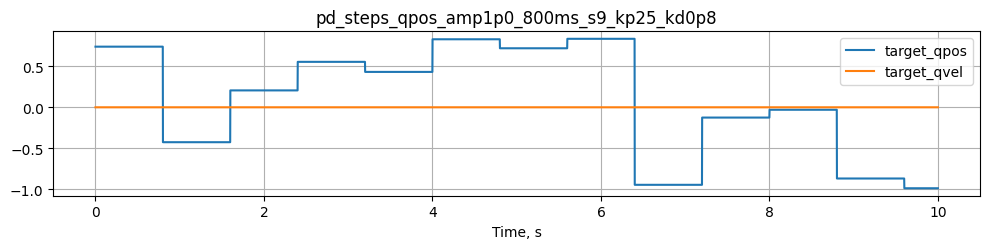

In [6]:
fig, ax = plt.subplots(len(RUN_PLAN), 1, figsize=(10, 2.6 * len(RUN_PLAN)), sharex=False)
if len(RUN_PLAN) == 1:
    ax = [ax]

for axis, spec in zip(ax, RUN_PLAN):
    t, target_qpos, target_qvel = build_targets(spec)
    axis.plot(t, target_qpos, label="target_qpos")
    axis.plot(t, target_qvel, label="target_qvel")
    axis.set_title(spec.name)
    axis.set_xlabel("Time, s")
    axis.grid()
    axis.legend()

plt.tight_layout()
plt.show()

## Collect Runs

In [7]:
def check_pd_binding() -> None:
    if not hasattr(encosid.SignalGenerator, "play_pd_signal"):
        raise RuntimeError(
            "encosid.SignalGenerator.play_pd_signal is not available. "
            "Rebuild and reinstall the Python extension after the C++ binding update."
        )


def response_to_frame(
    t: np.ndarray,
    target_qpos: np.ndarray,
    target_qvel: np.ndarray,
    response,
    kp: float,
    kd: float,
    qpos_zero: float | None = None,
) -> tuple[pd.DataFrame, float]:
    qpos_raw, qvel, _qcur = map(lambda values: np.asarray(values, dtype=float), response)
    qpos_unshifted = unwrap_motor_position(qpos_raw)
    if qpos_zero is None:
        if len(qpos_unshifted) == 0:
            raise ValueError("Cannot infer qpos_zero from an empty response")
        qpos_zero = float(qpos_unshifted[0])
    qpos = qpos_unshifted - qpos_zero

    if not (len(t) == len(target_qpos) == len(target_qvel) == len(qpos) == len(qvel)):
        raise ValueError(
            "Signal and response lengths differ: "
            f"time={len(t)}, target_qpos={len(target_qpos)}, "
            f"target_qvel={len(target_qvel)}, qpos={len(qpos)}, qvel={len(qvel)}"
        )

    qtorque_cmd = kp * (target_qpos - qpos) + kd * (target_qvel - qvel)

    return pd.DataFrame(
        {
            "time_s": t,
            "qpos": qpos,
            "qpos_unshifted": qpos_unshifted,
            "qvel": qvel,
            # Compatibility column: in this PD notebook qact means target qpos.
            "qact": target_qpos,
            "target_qvel": target_qvel,
            "qtorque_cmd": qtorque_cmd,
            "kp": kp,
            "kd": kd,
        }
    ), qpos_zero


def report_run(df: pd.DataFrame, run_name: str) -> None:
    abs_qvel = df["qvel"].abs()
    near_limit = abs_qvel >= QVEL_WARNING_LIMIT
    torque_summary = ""
    if "qtorque_cmd" in df.columns:
        torque_summary = f", qtorque_cmd range [{df['qtorque_cmd'].min():.3f}, {df['qtorque_cmd'].max():.3f}]"
    print(
        f"{run_name}: qpos range [{df['qpos'].min():.3f}, {df['qpos'].max():.3f}] rad, "
        f"unshifted qpos range [{df['qpos_unshifted'].min():.3f}, {df['qpos_unshifted'].max():.3f}] rad, "
        f"qvel range [{df['qvel'].min():.3f}, {df['qvel'].max():.3f}] rad/s, "
        f"target qpos range [{df['qact'].min():.3f}, {df['qact'].max():.3f}]"
        f"{torque_summary}"
    )
    if near_limit.any():
        pct = 100.0 * near_limit.mean()
        print(
            f"WARNING: {run_name} has {near_limit.sum()} samples ({pct:.2f}%) "
            f"with |qvel| >= {QVEL_WARNING_LIMIT}. These are close to the "
            f"+/-{QVEL_FEEDBACK_LIMIT} rad/s feedback encoding limit."
        )
    if "qtorque_cmd" in df.columns:
        high_torque = df["qtorque_cmd"].abs() >= QTORQUE_CMD_WARNING_LIMIT
        if high_torque.any():
            pct = 100.0 * high_torque.mean()
            print(
                f"WARNING: {run_name} has {high_torque.sum()} samples ({pct:.2f}%) "
                f"with |qtorque_cmd| >= {QTORQUE_CMD_WARNING_LIMIT}."
            )


def build_return_to_zero_targets(
    start_qpos: float,
    duration_s: float = RETURN_TO_ZERO_DURATION_S,
    target_qpos: float = RETURN_TO_ZERO_TARGET_QPOS,
    dt_ms: float = DT_MS,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    t = time_axis(duration_s, dt_ms)
    target_qpos_signal = linear_signal(t, start_qpos, target_qpos)
    target_qvel_signal = estimate_target_velocity(t, target_qpos_signal, 0.0, "linear")

    max_abs_qpos = np.max(np.abs(target_qpos_signal), initial=0.0)
    max_abs_qvel = np.max(np.abs(target_qvel_signal), initial=0.0)
    if max_abs_qpos > MAX_ABS_TARGET_QPOS:
        raise ValueError(
            f"Return-to-zero target exceeds MAX_ABS_TARGET_QPOS={MAX_ABS_TARGET_QPOS}: "
            f"max abs target qpos is {max_abs_qpos:.3f}"
        )
    if max_abs_qvel > MAX_ABS_TARGET_QVEL:
        raise ValueError(
            f"Return-to-zero target exceeds MAX_ABS_TARGET_QVEL={MAX_ABS_TARGET_QVEL}: "
            f"max abs target qvel is {max_abs_qvel:.3f}"
        )
    return t, target_qpos_signal, target_qvel_signal


def move_to_zero_after_run(df: pd.DataFrame, dt_ms: float = DT_MS) -> None:
    if df.empty:
        print("Skipping return-to-zero: run dataframe is empty.")
        return

    start_qpos = float(df["qpos_unshifted"].iloc[-1])
    if abs(start_qpos - RETURN_TO_ZERO_TARGET_QPOS) < 1e-3:
        print("Return-to-zero skipped: motor is already near zero.")
        return

    t, target_qpos, target_qvel = build_return_to_zero_targets(start_qpos, dt_ms=dt_ms)
    print(
        f"Returning to zero: {start_qpos:.3f} -> {RETURN_TO_ZERO_TARGET_QPOS:.3f} rad "
        f"over {t[-1] + dt_ms * 1e-3:.3f} s, "
        f"kp={RETURN_TO_ZERO_KP}, kd={RETURN_TO_ZERO_KD}"
    )
    gen = encosid.SignalGenerator(MOTOR_IF, MOTOR_ID)
    gen.play_pd_signal(target_qpos.tolist(), target_qvel.tolist(), RETURN_TO_ZERO_KP, RETURN_TO_ZERO_KD, dt_ms)
    print("Return-to-zero completed.")


def collect_run(
    spec: RunSpec,
    output_dir: Path = OUTPUT_DIR,
    dt_ms: float = DT_MS,
    qpos_zero: float | None = None,
) -> tuple[pd.DataFrame, float]:
    check_pd_binding()
    t, target_qpos, target_qvel = build_targets(spec, dt_ms)
    gen = encosid.SignalGenerator(MOTOR_IF, MOTOR_ID)

    print(f"Starting {spec.name}: {len(target_qpos)} samples at dt={dt_ms} ms, kp={spec.kp}, kd={spec.kd}")
    started_at = time.time()
    response = gen.play_pd_signal(target_qpos.tolist(), target_qvel.tolist(), spec.kp, spec.kd, dt_ms)
    elapsed_s = time.time() - started_at
    print(f"Finished {spec.name} in {elapsed_s:.2f} s")

    df, qpos_zero = response_to_frame(t, target_qpos, target_qvel, response, kp=spec.kp, kd=spec.kd, qpos_zero=qpos_zero)
    report_run(df, spec.name)

    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{spec.name}.csv"
    df.to_csv(output_path, index=False)
    print(f"Saved {len(df)} rows to {output_path}")
    return df, qpos_zero


def collect_all(run_plan: list[RunSpec] = RUN_PLAN) -> dict[str, pd.DataFrame]:
    collected = {}
    qpos_zero = None
    for spec in run_plan:
        collected[spec.name], qpos_zero = collect_run(spec, qpos_zero=qpos_zero)
        print(f"Using shared qpos_zero={qpos_zero:.6f} rad")
        if RETURN_TO_ZERO_AFTER_RUN:
            move_to_zero_after_run(collected[spec.name])
            time.sleep(RETURN_TO_ZERO_PAUSE_S)
        else:
            time.sleep(1.0)
    return collected

In [8]:
if RUN_COLLECTION:
    collected = collect_all(RUN_PLAN)
else:
    print("RUN_COLLECTION is False. Set it to True only when the motor is safe to run.")
    collected = {}

Starting pd_steps_qpos_amp1p0_800ms_s9_kp25_kd0p8: 10000 samples at dt=1 ms, kp=25.0, kd=0.8
Finished pd_steps_qpos_amp1p0_800ms_s9_kp25_kd0p8 in 10.27 s
pd_steps_qpos_amp1p0_800ms_s9_kp25_kd0p8: qpos range [-1.612, 1.080] rad, unshifted qpos range [-1.612, 1.080] rad, qvel range [-9.521, 7.842] rad/s, target qpos range [-0.989, 0.836], qtorque_cmd range [-38.649, 18.519]
Saved 10000 rows to /home/slava/projects/encos-sys-id/data/raw_pd_encos_servant/pd_steps_qpos_amp1p0_800ms_s9_kp25_kd0p8.csv
Using shared qpos_zero=0.000000 rad
Returning to zero: -0.787 -> 0.000 rad over 3.000 s, kp=10.0, kd=1.0
Return-to-zero completed.
